<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/ACTIVIDAD5_11_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TALLER  05-11-25
#Hamerson Joel Piarpuezan

# Comparación de Modulación Digital: ASK, PSK y FSK

---

## 🔹 1. Amplitude Shift Keying (ASK)

**Definición:**
La modulación **ASK** (modulación por desplazamiento de amplitud) varía **la amplitud de la portadora** según los bits de entrada. Cuando el bit es **`1`**, la portadora tiene una amplitud alta, y cuando es **`0`**, su amplitud disminuye o puede ser nula.

**Ecuación:**
$$
s(t) = \text{rect}(t) \cdot A_c \cos(2\pi f_c t)
$$
donde:
* $A_c$: amplitud de la portadora.
* $f_c$: frecuencia de la portadora.
* $\text{rect}(t)$: ventana rectangular que define el tiempo activo del símbolo.

**Explicación visual:**
* El **$\text{rect}(t)$** encierra **todas** las gaussianas o pulsos.
* Las gaussianas correspondientes a **`1`** tienen **mayor amplitud**.
* Las gaussianas de **`0`** tienen **amplitud menor o nula**.


---

## 🔹 2. Phase Shift Keying (PSK)

**Definición:**
En **PSK** (modulación por desplazamiento de fase), la **fase de la portadora cambia** dependiendo del bit transmitido. La amplitud permanece constante, pero la fase cambia (por ejemplo, $0^\circ$ para un **`0`** y $180^\circ$ para un **`1`**).

**Ecuación:**
$$
s(t) = A_c \cos(2\pi f_c t + \pi \cdot \text{rect}(t))
$$
donde:
* $\pi \cdot \text{rect}(t)$ produce un cambio de fase de $180^\circ$ cuando el bit es **`1`**.

**Explicación visual:**
* El **$\text{rect}(t)$** también encierra **todas** las gaussianas.
* La amplitud de todas las gaussianas es **igual**.
* Los cambios se observan en la **fase** (un cambio abrupto de $180^\circ$ para BPSK):
    * Fase base ($\approx 0^\circ$) $\rightarrow$ bit **`0`**.
    * Fase invertida ($\approx 180^\circ$) $\rightarrow$ bit **`1`**.


---

## 🔹 3. Frequency Shift Keying (FSK)

**Definición:**
En **FSK** (modulación por desplazamiento de frecuencia), la información se transmite **variando la frecuencia** de la portadora. Un bit **`1`** se asocia a una frecuencia $f_1$ y un bit **`0`** a otra frecuencia $f_0$.

**Ecuación:**
$$
s(t) =
\begin{cases}
A_c \cos(2\pi f_1 t), & \text{si } \text{rect}(t) = 1 \\
A_c \cos(2\pi f_0 t), & \text{si } \text{rect}(t) = 0
\end{cases}
$$
donde:
* $f_1 > f_0$, generalmente.
* $\text{rect}(t)$ actúa como **selector temporal** de la frecuencia activa.

**Explicación visual:**
* El **$\text{rect}(t)$** solo encierra las gaussianas de valor **`1`** en esta representación simplificada.
* Las gaussianas de **`1`** tienen **más oscilaciones** (**frecuencia alta**, $f_1$).
* Las de **`0`** tienen **menos oscilaciones** (**frecuencia baja**, $f_0$).


---

##  Interpretación del $\text{rect}(t)$

El término $\text{rect}(t)$ es una **ventana temporal** que:
* Indica **cuándo** está activo cada símbolo.
* Permite "recortar" el tiempo de cada pulso dentro del tren de bits.
* En el contexto general de las ecuaciones mostradas:
    * En **ASK** y **PSK**, modula la portadora.
    * En **FSK**, selecciona cuál de las dos frecuencias es activa en ese momento.

---
**Conclusión:**
Cada tipo de modulación cambia un aspecto diferente de la portadora:
* **ASK:** amplitud
* **PSK:** fase
* **FSK:** frecuencia

El $\text{rect}(t)$ actúa como una ventana o marca temporal para indicar **dónde vive cada símbolo** dentro del tren de bits, ayudando al receptor a identificar las zonas activas.

#CODIGO BASE

#Modulación Digital: ASK, W-ASK,W-PSK, W-FSK, B-PSK, B-FSK, CPM

#ASK

#  Especificaciones para Simulación de Modulación Digital

A continuación, se presentan las variables y funciones para el **Código Principal** de la simulación, utilizando notación matemática:

## 1. Código Principal

**Secuencia de bits de entrada ($d$):**
La secuencia de datos binarios a modular es:
$$
d = \{0, 1, 1, 0, 0, 1\}
$$

**Dominio de los bits individuales ($d_i$):**
Cada elemento $d_i$ en la secuencia $d$ pertenece al conjunto de valores binarios:
$$
d_i \in \{0, 1\}, \quad \text{donde } i = 0, 1, \dots, N-1 \text{ (índice del bit)}
$$

**Amplitudes de la señal ($a_i$):**
Las amplitudes que se utilizarán para la modulación (posiblemente ASK) pertenecen al conjunto de los números reales positivos:
$$
a_i \in \{a_0, a_1, \dots \}, \quad \text{donde } a_i \in \mathbb{R}^+
$$

**Función de pulso base ($v_i(t)$):**
Se define una función rectangular $\text{rect}_{\tau}(t)$ (o $\text{rect}(t/\tau)$) para cada pulso, la cual está activa por un tiempo $\tau$ (duración del símbolo).
$$
v_i(t) = \text{rect}_{\tau}(t), \quad \forall t \in \text{TAO}, \quad \forall i
$$
*Nota: $\text{TAO}$ representa el intervalo temporal del pulso, $\tau$.*

**Componente de fase/ángulo ($\alpha_i(t)$):**
El componente de fase angular para la modulación (posiblemente PSK o QPSK) se establece a cero:
$$
\alpha_i(t) = 0, \quad \forall i
$$

---
**Objetivo de la simulación:** Implementar una modulación digital (probablemente **ASK** o una base de modulación genérica) con estos parámetros iniciales.

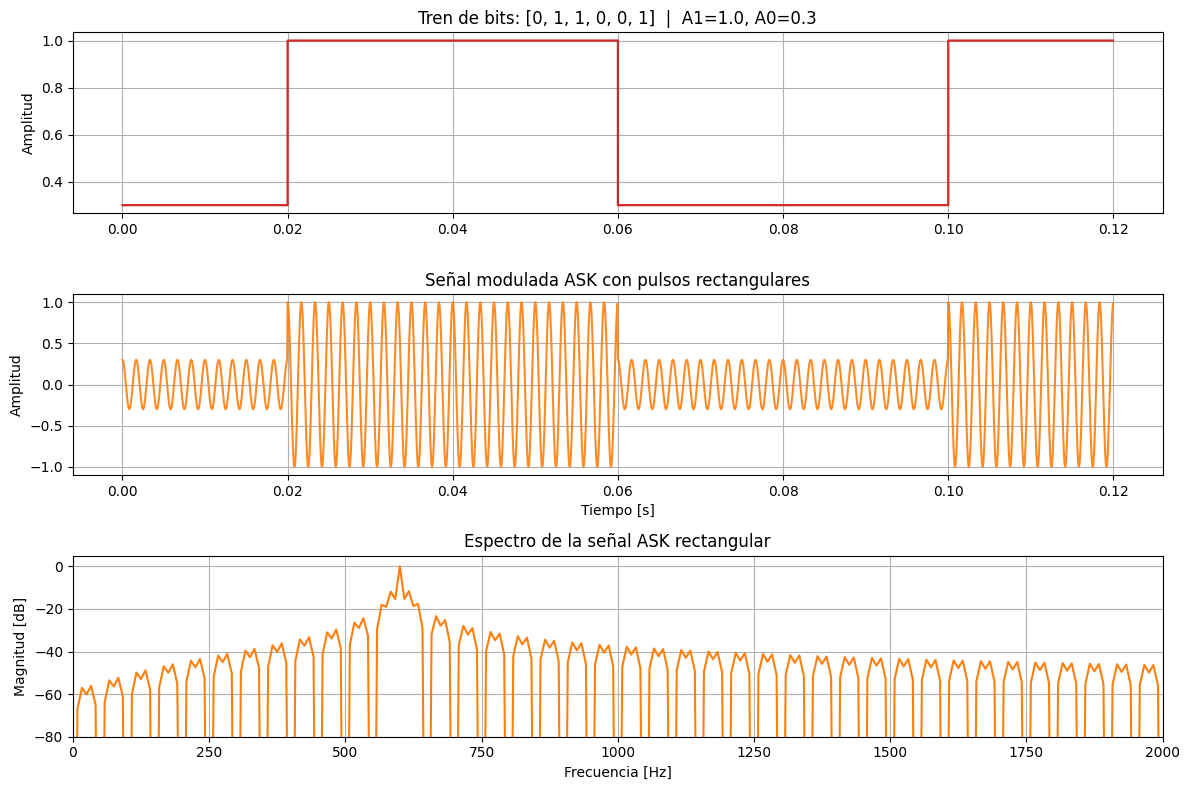

In [ ]:
# =============================================
# Código principal corregido (rect con amplitud en ceros)
# =============================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parámetros base
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])  # Secuencia binaria
fs = 20000                           # Frecuencia de muestreo [Hz]
Tsym = 0.02                          # Duración del símbolo [s]
fc = 600                             # Frecuencia portadora [Hz]
phi0 = 0                             # Fase inicial
A1 = 1.0                             # Amplitud para bit 1
A0 = 0.3                             # Amplitud para bit 0 (puedes ajustar entre 0 y 1)

t_sym = np.arange(0, Tsym, 1/fs)     # Tiempo por símbolo
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

# -----------------------
# Señal rectangular base (rect_Tao)
# -----------------------
m_t = np.zeros_like(t)
for k, b in enumerate(bits):
    amp = A1 if b == 1 else A0       # Asignar amplitud según bit
    m_t[k*Nsym:(k+1)*Nsym] = amp

carrier = np.cos(2*np.pi*fc*t + phi0)
s_rect = m_t * carrier

# -----------------------
# FFT / espectros
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    mag_db = 20*np.log10(mag / (mag.max() + 1e-12))
    return f, mag_db

f, spec_rect = fft_mag_db(s_rect, fs)

# -----------------------
# Gráficas
# -----------------------
plt.figure(figsize=(12,8))

# 1) Tren de bits (niveles de amplitud)
plt.subplot(3,1,1)
plt.step(t, m_t, where='post', color='C3', linewidth=1.6)
plt.title(f'Tren de bits: {bits.tolist()}  |  A1={A1}, A0={A0}')
plt.ylabel('Amplitud')
plt.grid(True)

# 2) Señal modulada rectangular ASK
plt.subplot(3,1,2)
plt.plot(t, s_rect, color='C1', alpha=0.9)
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [s]')
plt.title('Señal modulada ASK con pulsos rectangulares')
plt.grid(True)

# 3) Espectro
plt.subplot(3,1,3)
plt.plot(f, spec_rect, color='C1')
plt.xlim(0, 2000)
plt.ylim(-80, 5)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Espectro de la señal ASK rectangular')
plt.grid(True)

plt.tight_layout()
plt.show()


#W-ASK

#  Especificaciones para Simulación de Modulación W-ASK (ASK con Pulso Gaussiano)

Esta modulación se basa en **ASK (Amplitude Shift Keying)**, pero reemplaza el pulso rectangular por un pulso **Gaussiano** (W-ASK, por *Windowed* o *Wave-shaped*). Este cambio es crucial para mejorar las propiedades espectrales de la señal.

## 1. Código Principal con Pulso Gaussiano (W-ASK)

**Secuencia de bits de entrada ($d$):**
La secuencia de datos binarios a modular es:
$$
d = \{0, 1, 1, 0, 0, 1\}
$$

**Dominio de los bits individuales ($d_i$):**
Cada elemento $d_i$ en la secuencia $d$ pertenece al conjunto de valores binarios:
$$
d_i \in \{0, 1\}, \quad \text{donde } i = 0, 1, \dots, N-1 \text{ (índice del bit)}
$$

**Amplitudes de la señal ($a_i$):**
Las amplitudes de la portadora se modulan según el bit. Pertenecen al conjunto de los números reales positivos:
$$
a_i \in \{a_0, a_1, \dots \}, \quad \text{donde } a_i \in \mathbb{R}^+
$$

**Función de pulso base original (Reemplazada):**
$$
v_{\text{original}}(t) = \text{rect}_{\tau}(t)
$$

**Función de pulso base nueva (Gaussiana):**
El pulso rectangular es reemplazado por un **pulso Gaussiano** ($\text{gauss}_{\tau}(t)$), que garantiza transiciones suaves de amplitud:
$$
v_i(t) = \text{gauss}_{\tau}(t), \quad \forall i
$$


**Componente de fase/ángulo ($\alpha_i(t)$):**
La fase se mantiene en cero, confirmando que la modulación opera **exclusivamente sobre la amplitud**:
$$
\alpha_i(t) = 0, \quad \forall i
$$

---
**Objetivo de la simulación (W-ASK):**
Implementar la modulación **ASK** utilizando un pulso **Gaussiano** para suavizar las transiciones de amplitud. El objetivo principal es generar un espectro de frecuencia mucho más **compacto** y con lóbulos laterales significativamente menos pronunciados que el ASK rectangular.

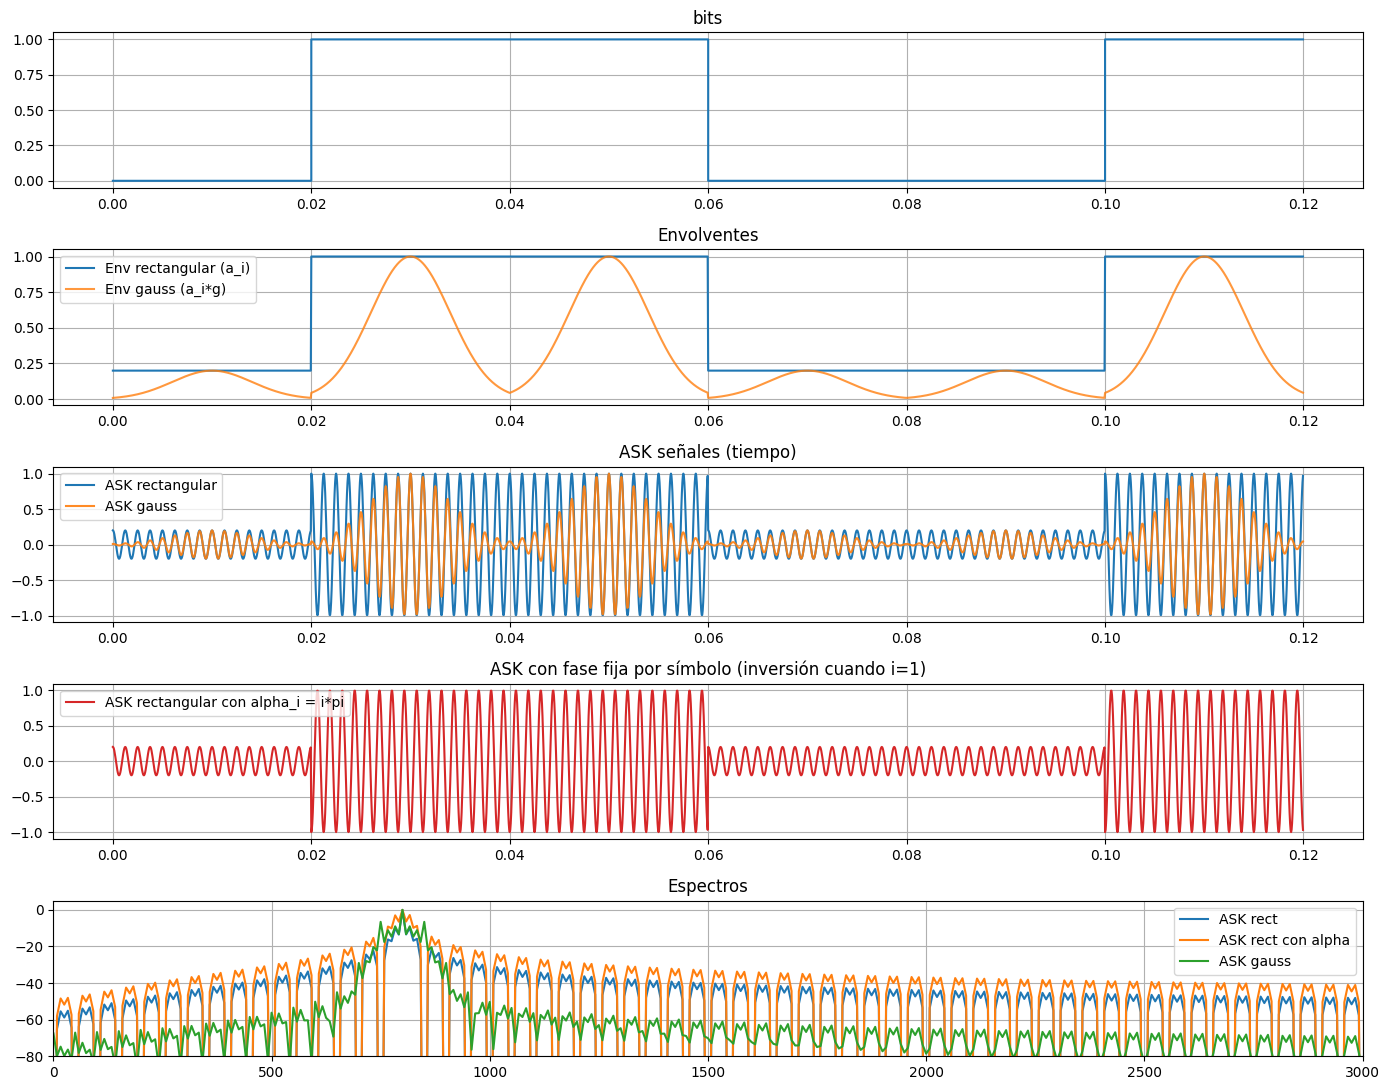

In [ ]:
# -----------------------------------------------------
# B) ASK: amplitud diferentes (a0,a1). Opcional: fases fijas α_i = i*pi
# -----------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Parámetros (misma secuencia)
bits = np.array([0,1,1,0,0,1])
fs = 20000
Tsym = 0.02
fc = 800
a0 = 0.2
a1 = 1.0
a_map = {0: a0, 1: a1}

sigma_frac = 0.20
sigma = sigma_frac*Tsym

t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

# construir envolventes gaussianas y rectangulares
env_rect = np.zeros_like(t)
env_gauss = np.zeros_like(t)
phi_fixed = np.zeros_like(t)   # fase fija por símbolo (opcional)

for k,b in enumerate(bits):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym
    env_rect[idx0:idx1] = a_map[int(b)]
    tt = (t[idx0:idx1] - (k*Tsym + Tsym/2.0))
    g = np.exp(-0.5*(tt/sigma)**2); g = g/(g.max()+1e-16)
    env_gauss[idx0:idx1] = a_map[int(b)] * g
    # fase fija opción 1: alpha_i = i*pi  (comenta/usa si quieres)
    i = int(b)
    alpha_i = i * np.pi               # si i=0 -> 0; i=1 -> pi (inversión)
    phi_fixed[idx0:idx1] = alpha_i

# señales ASK (con y sin fase fija aplicada)
s_ask_rect = env_rect * np.cos(2*np.pi*fc*t)            # ASK clásico
s_ask_rect_phase = env_rect * np.cos(2*np.pi*fc*t + phi_fixed)  # ASK con fase fija por símbolo
s_ask_gauss = env_gauss * np.cos(2*np.pi*fc*t)

# FFT
def fft_mag_db(x, fs):
    N = len(x); X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs)); mag = np.abs(X)
    return f, 20*np.log10(mag/(mag.max()+1e-12))

f, sp_rect = fft_mag_db(s_ask_rect, fs)
_, sp_rect_ph = fft_mag_db(s_ask_rect_phase, fs)
_, sp_gauss = fft_mag_db(s_ask_gauss, fs)

# Plots
plt.figure(figsize=(14,11))
plt.subplot(5,1,1)
plt.step(t, bits.repeat(Nsym), where='post', label='bits'); plt.title('bits'); plt.grid(True)

plt.subplot(5,1,2)
plt.plot(t, env_rect, label='Env rectangular (a_i)'); plt.plot(t, env_gauss, label='Env gauss (a_i*g)', alpha=0.8)
plt.legend(); plt.title('Envolventes'); plt.grid(True)

plt.subplot(5,1,3)
plt.plot(t, s_ask_rect, label='ASK rectangular'); plt.plot(t, s_ask_gauss, label='ASK gauss', alpha=0.9)
plt.legend(); plt.title('ASK señales (tiempo)'); plt.grid(True)

plt.subplot(5,1,4)
plt.plot(t, s_ask_rect_phase, label='ASK rectangular con alpha_i = i*pi', color='C3')
plt.legend(); plt.title('ASK con fase fija por símbolo (inversión cuando i=1)'); plt.grid(True)

plt.subplot(5,1,5)
plt.plot(f, sp_rect, label='ASK rect'); plt.plot(f, sp_rect_ph, label='ASK rect con alpha'); plt.plot(f, sp_gauss, label='ASK gauss')
plt.xlim(0,3000); plt.ylim(-80,5); plt.legend(); plt.title('Espectros'); plt.grid(True)

plt.tight_layout(); plt.show()

#W-PSK

#  Especificaciones para Simulación de Modulación W-PSK (BPSK con Pulso Gaussiano)

Esta configuración describe una modulación **W-PSK** (Windowed/Wave-shaped PSK), donde la información se codifica **únicamente en la fase** ($\alpha_i(t)$) de la portadora ($\mathbf{0^\circ}$ o $\mathbf{180^\circ}$), mientras que la amplitud ($a_i$) se mantiene constante y la forma del pulso base es **Gaussiana**.

## 1. Código Principal: W-PSK

**Secuencia de bits de entrada ($d$):**
La secuencia de datos binarios a modular es:
$$
d = \{0, 1, 1, 0, 0, 1\}
$$

**Dominio de los bits individuales ($d_i$):**
Cada elemento $d_i$ en la secuencia $d$ pertenece al conjunto de valores binarios:
$$
d_i \in \{0, 1\}, \quad \forall i
$$

**Amplitudes de la señal ($a_i$):**
La amplitud se mantiene **constante** ($\mathbf{A}$) durante todo el tiempo, ya que la información está solo en la fase:
$$
a_i = A, \quad \text{donde } A \in \mathbb{R}^+
$$

**Función de pulso base ($v_i(t)$):**
Se utiliza la **Opción Gaussiana** para suavizar las transiciones de fase y reducir el ancho de banda:
$$
v_i(t) = \text{gauss}_{\tau}(t), \quad \forall i, t \in \tau
$$


**Componente de fase/ángulo ($\alpha_i(t)$):**
La fase es **constante** durante el símbolo y cambia $\pi$ radianes ($180^\circ$) cuando el bit $d_i$ es `1`:
$$
\alpha_i(t) = d_i \cdot \pi, \quad \forall i, t \in \tau
$$
* Si $d_i = 0 \implies \alpha_i(t) = 0$ (Fase $0^\circ$)
* Si $d_i = 1 \implies \alpha_i(t) = \pi$ (Fase $180^\circ$)

---
**Objetivo de la simulación:** Implementar la modulación **W-PSK (BPSK Gaussiano)**. La amplitud se modula por el pulso Gaussiano, pero la fase es $\mathbf{0}$ o $\mathbf{\pi}$. El uso del pulso Gaussiano ayuda a suavizar el salto de $180^\circ$ de fase, **reduciendo el ancho de banda** (CP-BPSK implícito).

<>:88: SyntaxWarning: invalid escape sequence '\p'
<>:88: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1846030261.py:88: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t, phi_time, label='Fase Lineal ($\phi(t) = C \cdot t$)');


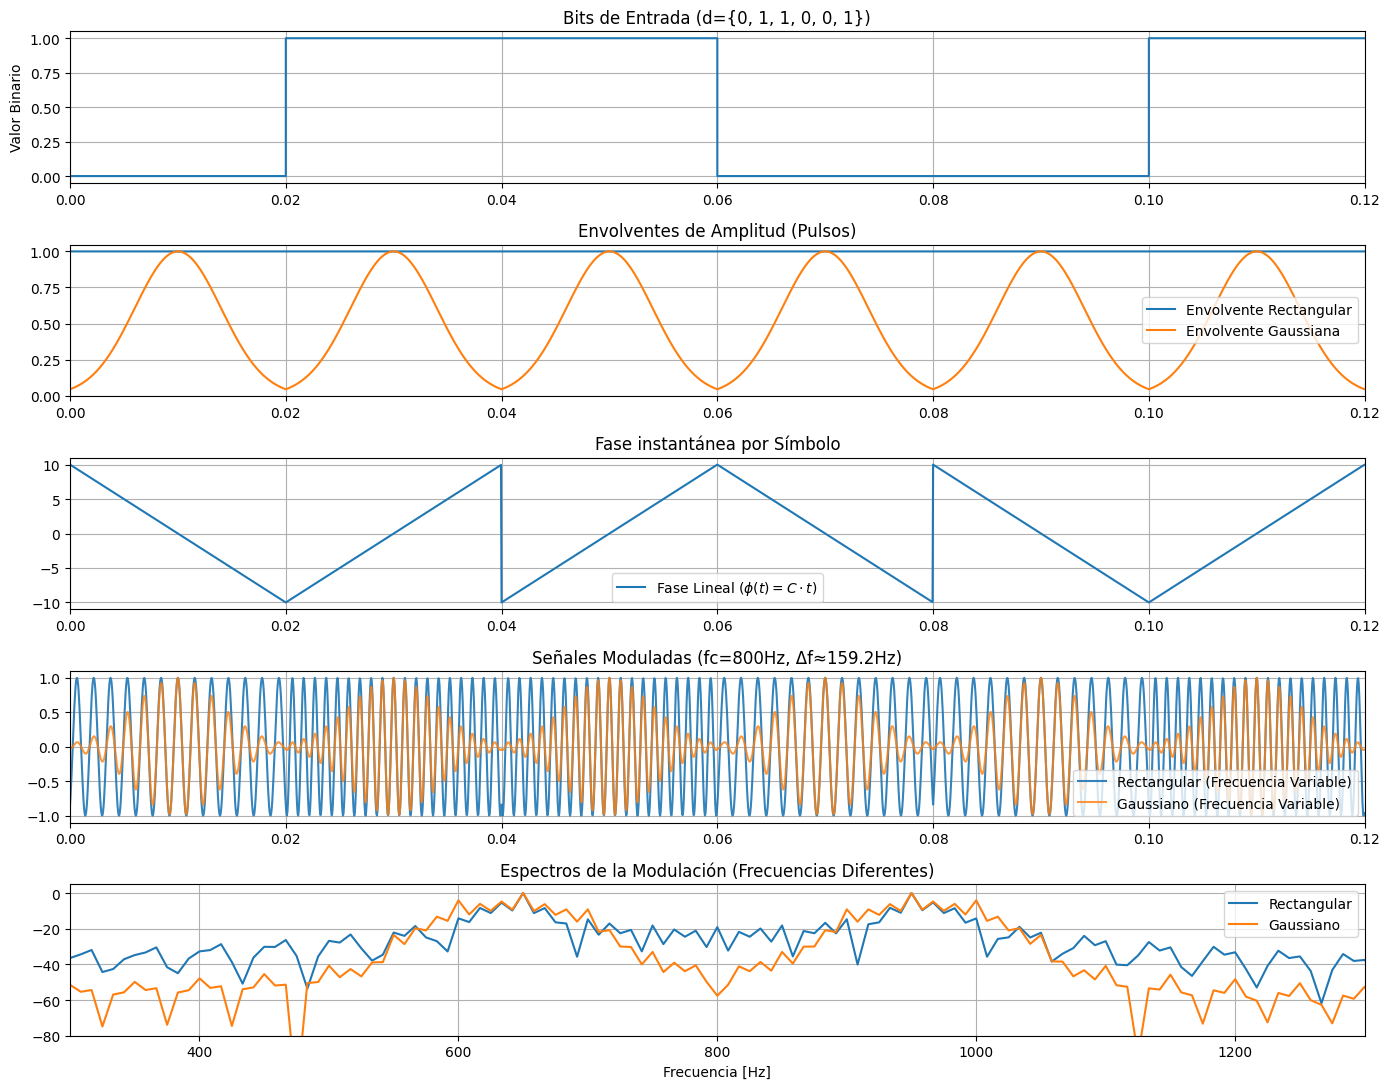

In [ ]:
# ====================================================================
# C) Modulación de Frecuencia/Fase (Fase Lineal)
#    Código corregido para mostrar los 6 símbolos (Gausianas) y los 6 Bits
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parámetros Base
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])  # Secuencia binaria: 6 símbolos
fs = 20000                          # Frecuencia de muestreo [Hz]
Tsym = 0.02                         # Duración del símbolo [s]
fc = 800                            # Frecuencia portadora [Hz]
a = 1.0                             # Amplitud constante
K_phi = 1000.0                      # Factor alto para visualizar el cambio de frecuencia

# Parámetros del Pulso Gaussiano
sigma_frac = 0.20
sigma = sigma_frac * Tsym

t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)
T_total = len(bits) * Tsym         # Tiempo total para los 6 símbolos (0.12 segundos)

# -----------------------
# Envolvente y Fase Lineal
# -----------------------
env_rect = np.ones_like(t) * a
env_gauss = np.zeros_like(t)
phi_time = np.zeros_like(t)

for k, b in enumerate(bits):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym
    i = int(b)

    # 1. Envolvente Gaussiana
    tt = t[idx0:idx1] - (k*Tsym + Tsym/2.0)
    g = np.exp(-0.5*(tt/sigma)**2); g = g / (g.max()+1e-16)
    env_gauss[idx0:idx1] = a * g

    # 2. Fase Lineal por Símbolo
    phi_time[idx0:idx1] = K_phi * (2*i - 1) * (t[idx0:idx1] - (k*Tsym + Tsym/2.0))

# -----------------------
# Señales Moduladas
# -----------------------
s_mod_rect = env_rect * np.cos(2*np.pi*fc*t + phi_time)
s_mod_gauss = env_gauss * np.cos(2*np.pi*fc*t + phi_time)

# -----------------------
# FFT / Espectros
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag / (mag.max() + 1e-12))

f, sp_rect = fft_mag_db(s_mod_rect, fs)
_, sp_gauss = fft_mag_db(s_mod_gauss, fs)

# -----------------------
# Gráficas
# -----------------------
plt.figure(figsize=(14, 11))

# 1) Bits de entrada (¡CORREGIDO!)
plt.subplot(5, 1, 1) # Usamos 5 subplots para incluir los bits y las envolventes
plt.step(t, bits.repeat(Nsym), where='post');
plt.xlim(0, T_total) # <--- Muestra los 6 bits
plt.title('Bits de Entrada (d={0, 1, 1, 0, 0, 1})');
plt.ylabel('Valor Binario');
plt.grid(True)


# 2) Envolventes (para ver los pulsos Gaussiano y Rectangular)
plt.subplot(5, 1, 2)
plt.plot(t, env_rect, label='Envolvente Rectangular');
plt.plot(t, env_gauss, label='Envolvente Gaussiana');
plt.xlim(0, T_total) # <--- Mostrar los 6 pulsos
plt.legend(); plt.title('Envolventes de Amplitud (Pulsos)'); plt.grid(True)

# 3) Fase Lineal (para confirmar la pendiente)
plt.subplot(5, 1, 3)
plt.plot(t, phi_time, label='Fase Lineal ($\phi(t) = C \cdot t$)');
plt.xlim(0, T_total) # <--- Mostrar todo
plt.legend(); plt.title('Fase instantánea por Símbolo'); plt.grid(True)

# 4) Señales Moduladas (Tiempo) - Aquí se ve el cambio de frecuencia en las 6 Gausianas
plt.subplot(5, 1, 4)
plt.plot(t, s_mod_rect, label='Rectangular (Frecuencia Variable)', alpha=0.9)
plt.plot(t, s_mod_gauss, label='Gaussiano (Frecuencia Variable)', alpha=0.8)
plt.xlim(0, T_total) # <--- Mostrar los 6 símbolos (0.12 segundos)
plt.legend(); plt.title(f'Señales Moduladas (fc={fc}Hz, Δf≈{K_phi/(2*np.pi):.1f}Hz)'); plt.grid(True)

# 5) Espectros
plt.subplot(5, 1, 5)
plt.plot(f, sp_rect, label='Rectangular');
plt.plot(f, sp_gauss, label='Gaussiano');
plt.xlim(fc - 500, fc + 500)
plt.ylim(-80, 5); plt.legend(); plt.title('Espectros de la Modulación (Frecuencias Diferentes)'); plt.grid(True)
plt.xlabel('Frecuencia [Hz]')


plt.tight_layout()
plt.show()

#W-FSK

#  Especificaciones para Simulación de Modulación W-FSK (FSK con Pulso Gaussiano/Fase Lineal)

Esta configuración describe la modulación **FSK** implementada mediante una **fase que varía linealmente** (una rampa con pendiente $/ \setminus$) dentro de cada símbolo $\tau$. El cambio en la pendiente de la fase ($\alpha_i(t)$) induce el **desplazamiento de frecuencia**, mientras que la amplitud ($a_i$) se mantiene constante. El objetivo es destacar el efecto de la **Opción Gaussiana** (W-FSK).

## 1. Código Principal: FSK (Fase Lineal)

**Secuencia de bits de entrada ($d$):**
La secuencia de datos binarios a modular es:
$$
d = \{0, 1, 1, 0, 0, 1\}
$$

**Dominio de los bits individuales ($d_i$):**
Cada elemento $d_i$ en la secuencia $d$ pertenece al conjunto de valores binarios:
$$
d_i \in \{0, 1\}, \quad \forall i
$$

**Representación de la señal modulada ($s(t)$):**
La señal modulada en el tiempo es:
$$
s(t) = a_i \cdot v_i(t) \cdot \cos(\omega_0 t + \alpha_i(t))
$$
donde $\omega_0 = 2\pi f_c$.

**Amplitudes de la señal ($a_i$):**
La amplitud se mantiene **constante** y positiva ($A$), ya que la información está en la fase/frecuencia:
$$
a_i \in \{a_0, a_1, \dots \}, \quad \text{donde } a_i \in \mathbb{R}^+
$$

**Función de pulso base ($v_i(t)$):**
Se permite la elección entre el pulso rectangular y el Gaussiano, ambos activos durante el intervalo de símbolo $\tau$:

* **Opción Rectangular:**
    $$
    v_i(t) = \text{rect}_{\tau}(t), \quad \forall i, t \in \tau
    $$
* **Opción Gaussiana (W-FSK):**
    $$
    v_i(t) = \text{gauss}_{\tau}(t), \quad \forall i, t \in \tau
    $$

**Componente de fase/ángulo ($\alpha_i(t)$) - Énfasis en la Pendiente:**
La fase es una **función lineal con pendiente** que depende del bit $d_i$. La notación $/ \setminus$ representa el factor de **pendiente** que define el desplazamiento de frecuencia (donde $t_{\text{local}}$ es el tiempo centrado en el símbolo):

$$
\alpha_i(t) = C \cdot (2d_i - 1) \cdot t_{\text{local}}
$$

Esta fórmula modela el comportamiento de las rampas (la "onda triangular" en la gráfica superior):
* Si $d_i = 1$: La pendiente es **positiva** ($+C \cdot t_{\text{local}}$) $\implies$ Frecuencia Alta ($f_c + \Delta f$).
* Si $d_i = 0$: La pendiente es **negativa** ($-C \cdot t_{\text{local}}$) $\implies$ Frecuencia Baja ($f_c - \Delta f$).

---
**Objetivo de la simulación:** Implementar la modulación **W-FSK** utilizando la fase lineal para inducir el cambio de frecuencia ($\Delta f$), destacando el efecto del pulso **Gaussiano** en las transiciones de frecuencia para **reducir el ancho de banda** (eficiencia espectral).

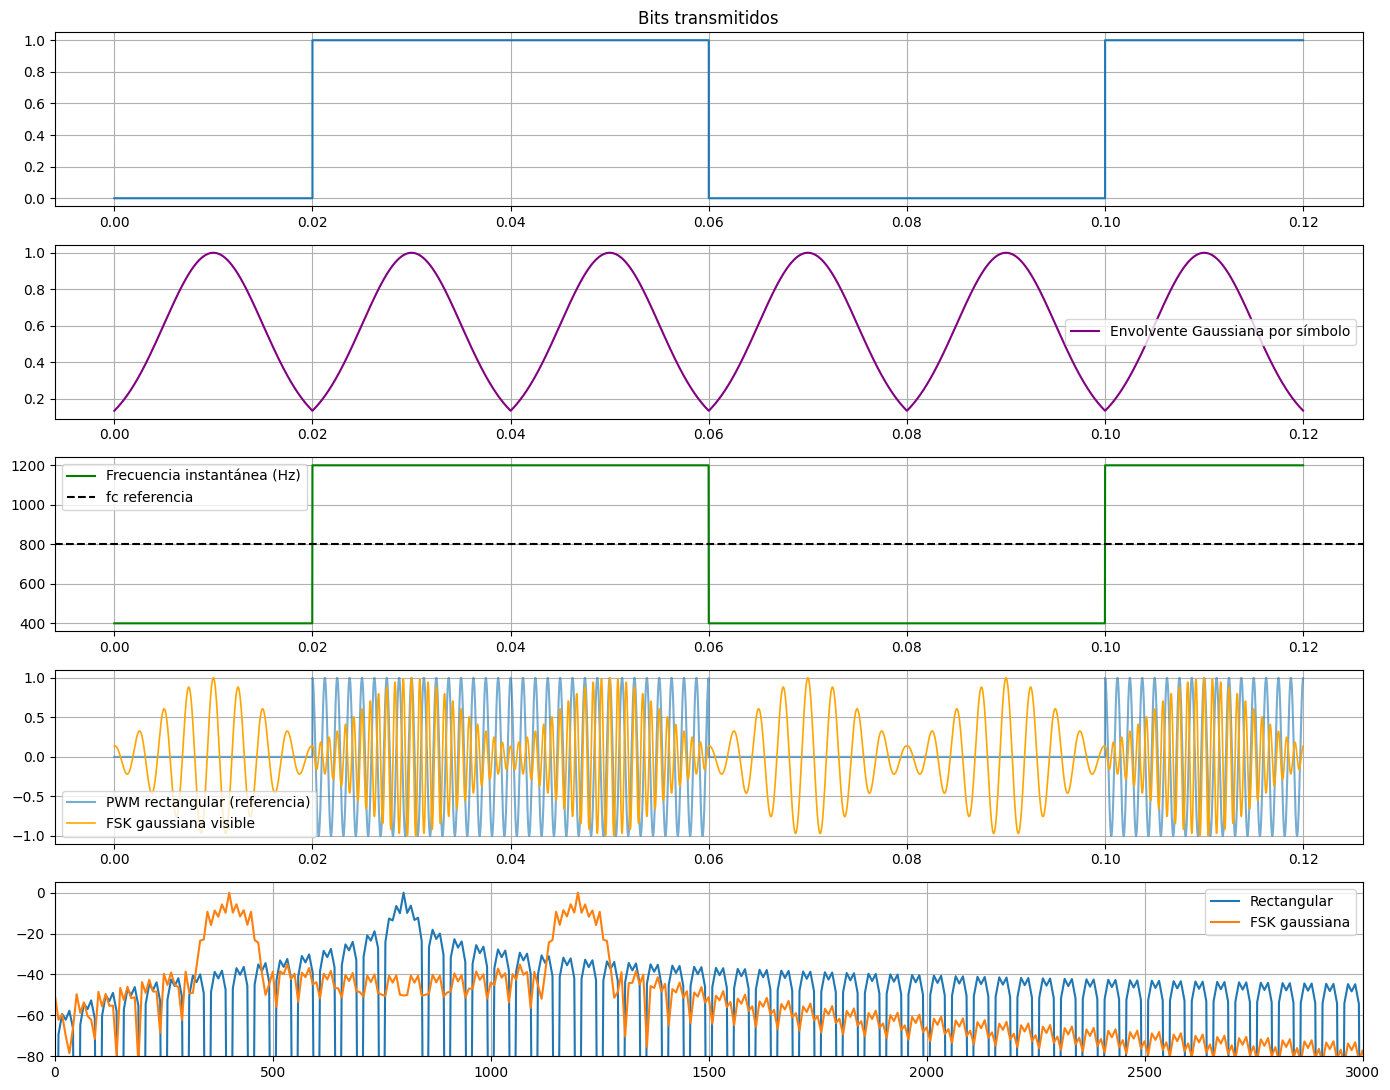

In [ ]:
# -----------------------------------------------------
# FSK con envolvente gaussiana visible entre símbolos
# Comparación con señal rectangular (PWM)
# -----------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
bits = np.array([0,1,1,0,0,1])
fs = 50000
Tsym = 0.02
a = 1.0
sigma_frac = 0.25
sigma = sigma_frac * Tsym
f0 = 400     # Hz para bit 0
f1 = 1200    # Hz para bit 1
fc = 800     # frecuencia central de referencia (para PWM rect)

# Tiempo total
t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

# Señales
s_fsk = np.zeros_like(t)
s_rect = np.zeros_like(t)
env_gauss = np.zeros_like(t)
f_inst = np.zeros_like(t)

# Construcción símbolo a símbolo
for k, b in enumerate(bits):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym
    tt = t[idx0:idx1] - (k*Tsym + Tsym/2)
    g = np.exp(-0.5*(tt/sigma)**2)
    g = g / g.max()
    env_gauss[idx0:idx1] = g

    # frecuencia por bit
    fbit = f1 if b == 1 else f0
    f_inst[idx0:idx1] = fbit
    s_fsk[idx0:idx1] = a * g * np.cos(2*np.pi*fbit*t[idx0:idx1])
    s_rect[idx0:idx1] = b * np.cos(2*np.pi*fc*t[idx0:idx1])  # referencia rectangular

# FFT
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag/(mag.max()+1e-12))

f, sp_rect = fft_mag_db(s_rect, fs)
_, sp_fsk = fft_mag_db(s_fsk, fs)

# -----------------------------------------------------
# Gráficos
# -----------------------------------------------------
plt.figure(figsize=(14,11))

plt.subplot(5,1,1)
plt.step(t, bits.repeat(Nsym), where='post')
plt.title('Bits transmitidos')
plt.grid(True)

plt.subplot(5,1,2)
plt.plot(t, env_gauss, color='purple', label='Envolvente Gaussiana por símbolo')
plt.legend(); plt.grid(True)

plt.subplot(5,1,3)
plt.plot(t, f_inst, label='Frecuencia instantánea (Hz)', color='green')
plt.axhline(fc, color='k', ls='--', label='fc referencia')
plt.legend(); plt.grid(True)

plt.subplot(5,1,4)
plt.plot(t, s_rect, label='PWM rectangular (referencia)', alpha=0.6)
plt.plot(t, s_fsk, label='FSK gaussiana visible', color='orange', linewidth=1.2)
plt.legend(); plt.grid(True)

plt.subplot(5,1,5)
plt.plot(f, sp_rect, label='Rectangular')
plt.plot(f, sp_fsk, label='FSK gaussiana')
plt.xlim(0,3000)
plt.ylim(-80,5)
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


#B-PSK

#  Especificaciones para Simulación de Modulación BPSK (Binary Phase Shift Keying)

Esta configuración define la modulación **BPSK**, donde la información se codifica mediante un **salto de fase** de $180^\circ$ ($\pi$ radianes). La amplitud es constante y se utiliza el pulso rectangular.

## 1. Código Principal: BPSK Estándar

**Secuencia de bits de entrada ($d$):**
La secuencia de datos binarios a modular es:
$$
d = \{0, 1, 1, 0, 0, 1\}
$$

**Dominio de los bits individuales ($d_i$):**
Cada elemento $d_i$ en la secuencia $d$ pertenece al conjunto de valores binarios:
$$
d_i \in \{0, 1\}, \quad \forall i
$$

**Representación de la señal modulada ($s(t)$):**
La señal modulada en el tiempo es:
$$
s(t) = a_i \cdot v_i(t) \cdot \cos(\omega_0 t + \alpha_i(t))
$$
donde $\omega_0 = 2\pi f_c$.

**Amplitudes de la señal ($a_i$):**
La amplitud se mantiene **constante** ($A$) y positiva, ya que BPSK no modula la potencia:
$$
a_i \in \{a_0, a_1, \dots \}, \quad \text{donde } a_i \in \mathbb{R}^+
$$

**Función de pulso base ($v_i(t)$):**
Se utiliza el pulso **rectangular**, lo que resulta en transiciones abruptas de fase y mayor ancho de banda:
$$
v_i(t) = \text{rect}_{\tau}(t), \quad \forall i, t \in \text{TAO}
$$


**Componente de fase/ángulo ($\alpha_i(t)$):**
La fase es **constante** durante el intervalo de símbolo ($\tau$) y cambia según el bit:
$$
\alpha_i(t) = d_i \cdot \pi
$$
* **Si $d_i = 0$:** $\alpha_i(t) = 0$ (Fase $0^\circ$)
* **Si $d_i = 1$:** $\alpha_i(t) = \pi$ (Fase $180^\circ$)

---
**Objetivo de la simulación:** Implementar **BPSK** utilizando el pulso rectangular. La señal debe mostrar un salto instantáneo de $180^\circ$ en cada transición de bit $0 \leftrightarrow 1$, manteniendo la amplitud constante.

<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3859908516.py:71: SyntaxWarning: invalid escape sequence '\p'
  plt.step(t, phi_bpsk, where='post', label='Fase BPSK (0 o $\pi$ rad)')
/tmp/ipython-input-3859908516.py:73: SyntaxWarning: invalid escape sequence '\p'
  plt.yticks([0, np.pi], ['0 rad', '$\pi$ rad (180°)',]) # Etiquetas claras para la fase


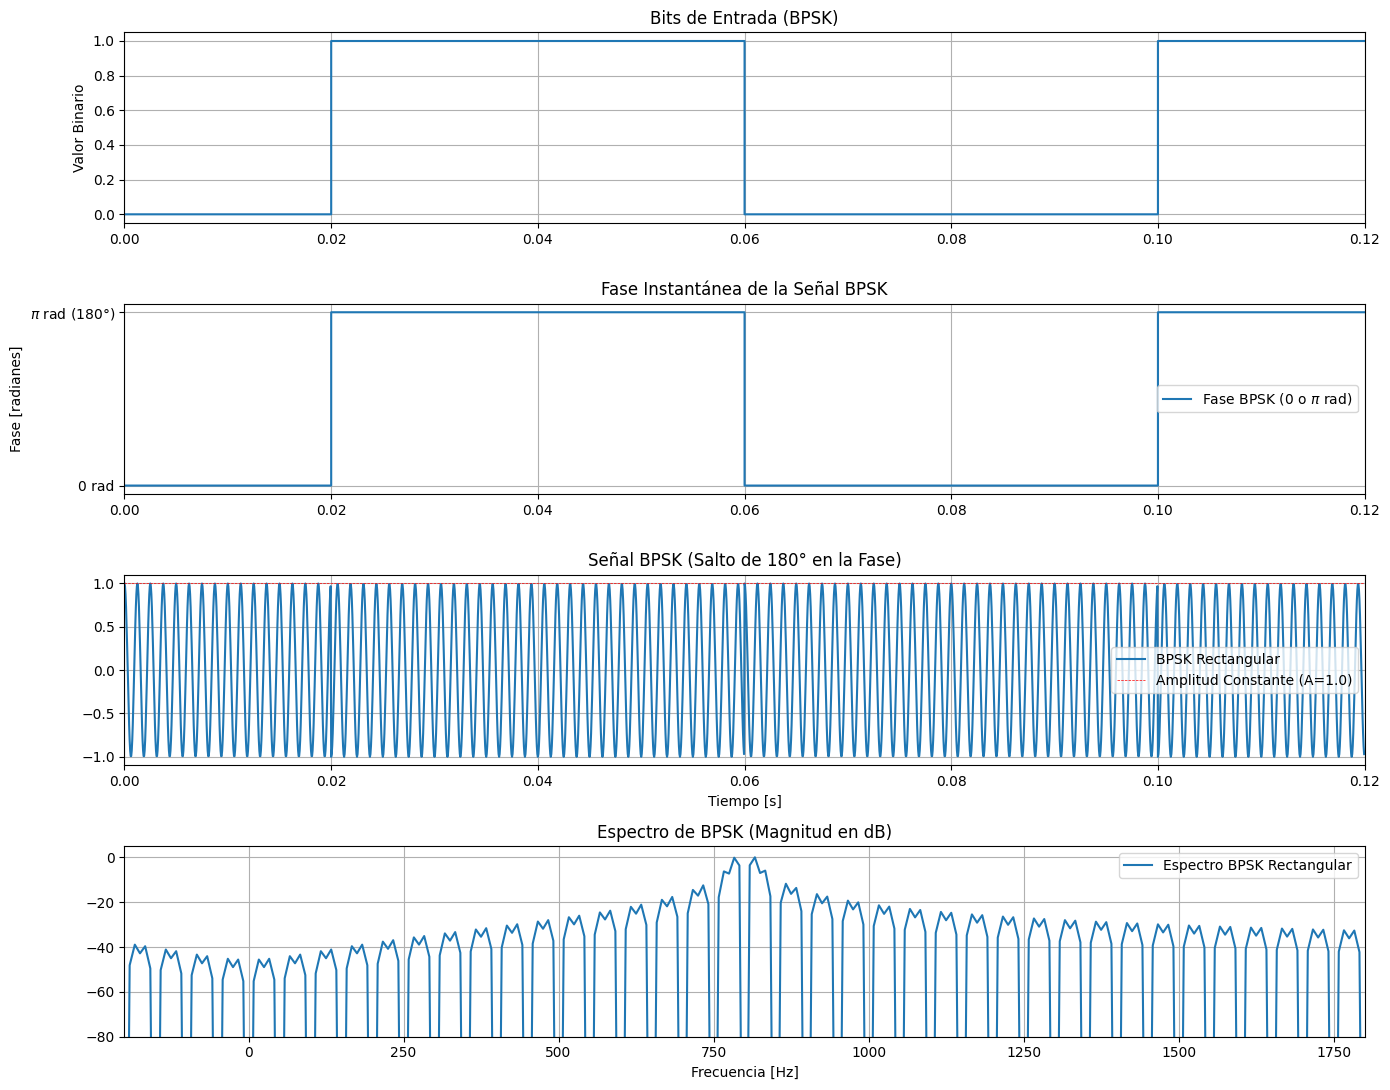

In [ ]:
# ====================================================================
# E) BPSK (Binary Phase Shift Keying) Estándar
#    Amplitud constante, Pulso Rectangular, Fase constante (0 o pi)
#    ¡Añadida gráfica de Fase Instantánea!
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parámetros Base
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])  # Secuencia binaria
fs = 20000                          # Frecuencia de muestreo [Hz]
Tsym = 0.02                         # Duración del símbolo [s]
fc = 800                            # Frecuencia portadora [Hz]
a = 1.0                             # Amplitud constante (A)
T_total = len(bits) * Tsym          # Tiempo total

# -----------------------
# Vectores de Tiempo y Amplitud
# -----------------------
t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

env_rect = np.ones_like(t) * a      # Envolvente Rectangular (Amplitud constante)
phi_bpsk = np.zeros_like(t)         # Fase de BPSK: 0 o pi

# -----------------------
# Generación de la Señal BPSK
# -----------------------
for k, b in enumerate(bits):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym
    i = int(b)

    # 1. Fase BPSK: alfai(t) = di * pi
    alpha_i = i * np.pi           # 0 si b=0, pi (180 deg) si b=1
    phi_bpsk[idx0:idx1] = alpha_i

# 2. Señal BPSK
# s(t) = A * rect(t) * cos(2*pi*fc*t + phi_bpsk)
s_bpsk = env_rect * np.cos(2*np.pi*fc*t + phi_bpsk)

# -----------------------
# FFT / Espectro
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag / (mag.max() + 1e-12))

f, sp_bpsk = fft_mag_db(s_bpsk, fs)

# -----------------------
# Gráficas
# -----------------------
plt.figure(figsize=(14, 11)) # Aumentamos ligeramente la altura para 4 subplots

# 1) Bits de entrada
plt.subplot(4, 1, 1) # Ahora es el subplot 1 de 4
plt.step(t, bits.repeat(Nsym), where='post');
plt.xlim(0, T_total)
plt.title('Bits de Entrada (BPSK)');
plt.ylabel('Valor Binario');
plt.grid(True)

# 2) Fase Instantánea (¡NUEVA GRÁFICA!)
plt.subplot(4, 1, 2) # Segundo subplot
plt.step(t, phi_bpsk, where='post', label='Fase BPSK (0 o $\pi$ rad)')
plt.xlim(0, T_total)
plt.yticks([0, np.pi], ['0 rad', '$\pi$ rad (180°)',]) # Etiquetas claras para la fase
plt.legend(); plt.title('Fase Instantánea de la Señal BPSK'); plt.grid(True)
plt.ylabel('Fase [radianes]')


# 3) Señal BPSK (Tiempo)
plt.subplot(4, 1, 3) # Tercer subplot
plt.plot(t, s_bpsk, label='BPSK Rectangular', color='C0')
plt.plot(t, env_rect, 'r--', linewidth=0.5, label='Amplitud Constante (A=1.0)')
plt.xlim(0, T_total)
plt.legend(); plt.title(f'Señal BPSK (Salto de {int(np.pi*180/np.pi)}° en la Fase)'); plt.grid(True)
plt.xlabel('Tiempo [s]')


# 4) Espectro
plt.subplot(4, 1, 4) # Cuarto subplot
plt.plot(f, sp_bpsk, label='Espectro BPSK Rectangular');
plt.xlim(fc - 1000, fc + 1000)
plt.ylim(-80, 5); plt.legend(); plt.title('Espectro de BPSK (Magnitud en dB)'); plt.grid(True)
plt.xlabel('Frecuencia [Hz]')


plt.tight_layout()
plt.show()

#B-PSK SIN ROMPIMIENTO DE FASE

#  Simulación de BPSK sin Rompimiento de Fase (CP-BPSK)

Esta modulación busca eliminar los saltos abruptos de fase de $180^\circ$ causados por el pulso rectangular, logrando así una **fase continua** y un **espectro más limpio**.

La continuidad de fase se logra al modular una señal de banda base $A(t)$ que tiene **transiciones suaves** (no instantáneas) entre los niveles de la constelación ($+A$ y $-A$), y envolverla con un pulso suave como el Gaussiano.

## 1. Implementación de la Fase Continua (CP-BPSK Implícito)

**Representación de la Señal (Banda Base):**
La modulación se realiza multiplicando la portadora por la señal de banda base $A(t)$ suavizada:
$$
s(t) = A(t) \cdot \cos(\omega_0 t)
$$
Donde $A(t)$ es la suma de los pulsos suavizados:
$$
A(t) = \sum_{k} A_k \cdot g(t-k T_{\text{sym}})
$$

**Asignación de Amplitud (Coeficientes de Constelación):**
* **Bit $d_i = 0$** $\implies$ Coeficiente de Banda Base $A_k = +1$
* **Bit $d_i = 1$** $\implies$ Coeficiente de Banda Base $A_k = -1$
La inversión de signo ($+1 \leftrightarrow -1$) es la que realiza el salto de fase de $180^\circ$. La **suavidad** del pulso $g(t)$ hace que este salto sea gradual, **eliminando el rompimiento instantáneo de fase**.

**Función de Pulso para Continuidad ($v_i(t)$):**
$$
v_i(t) = \text{gauss}_{\tau}(t), \quad \forall i, t \in \text{TAO}
$$

---
**Objetivo de la simulación:** Implementar BPSK utilizando el pulso Gaussiano y la representación de banda base suavizada. La señal debe mostrar transiciones de fase **suaves** y el **espectro debe ser más compacto** que el BPSK rectangular.

# 💡 Solución para el BPSK sin Rompimiento de Fase: El Pulso Gaussiano

La **función de pulso Gaussiana** (o cualquier pulso de forma suave) se implementa en la modulación BPSK para **evitar la discontinuidad de fase de 180° instantánea** que ocurre en las transiciones de bit cuando se utiliza un pulso rectangular.

## 1. El Problema del Pulso Rectangular (Discontinuidad)

En el BPSK estándar con pulso rectangular, la señal de banda base pasa de $+A$ a $-A$ (o viceversa) de forma **abrupta** en el borde del símbolo. Esta transición instantánea causa dos problemas serios:

* **Rompimiento de Fase:** La portadora debe invertir su fase ($180^\circ$) en un tiempo cero, lo que implica que la amplitud de la señal pasa momentáneamente por un valor de cero.
* **Ancho de Banda Excesivo:** Esta discontinuidad abrupta inyecta energía en frecuencias muy altas, haciendo que el **espectro sea muy ancho** y tenga lóbulos laterales grandes. Esto reduce la eficiencia espectral y aumenta la **Interferencia de Canal Adyacente (ACI)**.

## 2. La Solución del Pulso Gaussiano (Continuidad)

La función Gaussiana ($\mathbf{g(t)}$) se utiliza como envolvente de la señal modulada por amplitud en la banda base para **suavizar la transición** del cambio de signo:

1.  **Suavizado de la Amplitud:** La Gaussiana es una función que cae suavemente a cero en los bordes del símbolo.
2.  **Continuidad de Fase:** Al multiplicar la señal de banda base por esta envolvente Gaussiana ($\mathbf{s(t) = A_k \cdot g(t) \cdot \cos(\omega_0 t)}$), forzamos a que la **amplitud de la señal caiga a cero de forma gradual** en el punto exacto donde la portadora debe invertir su fase.
3.  **Resultado:** Al pasar por cero de manera gradual, **se elimina el salto instantáneo de $180^\circ$**, logrando una señal con **Fase Continua** (CP-BPSK implícito).

Este suavizado temporal resulta en un **Espectro más Limpio y Compacto**, reduciendo drásticamente la interferencia con otros canales.

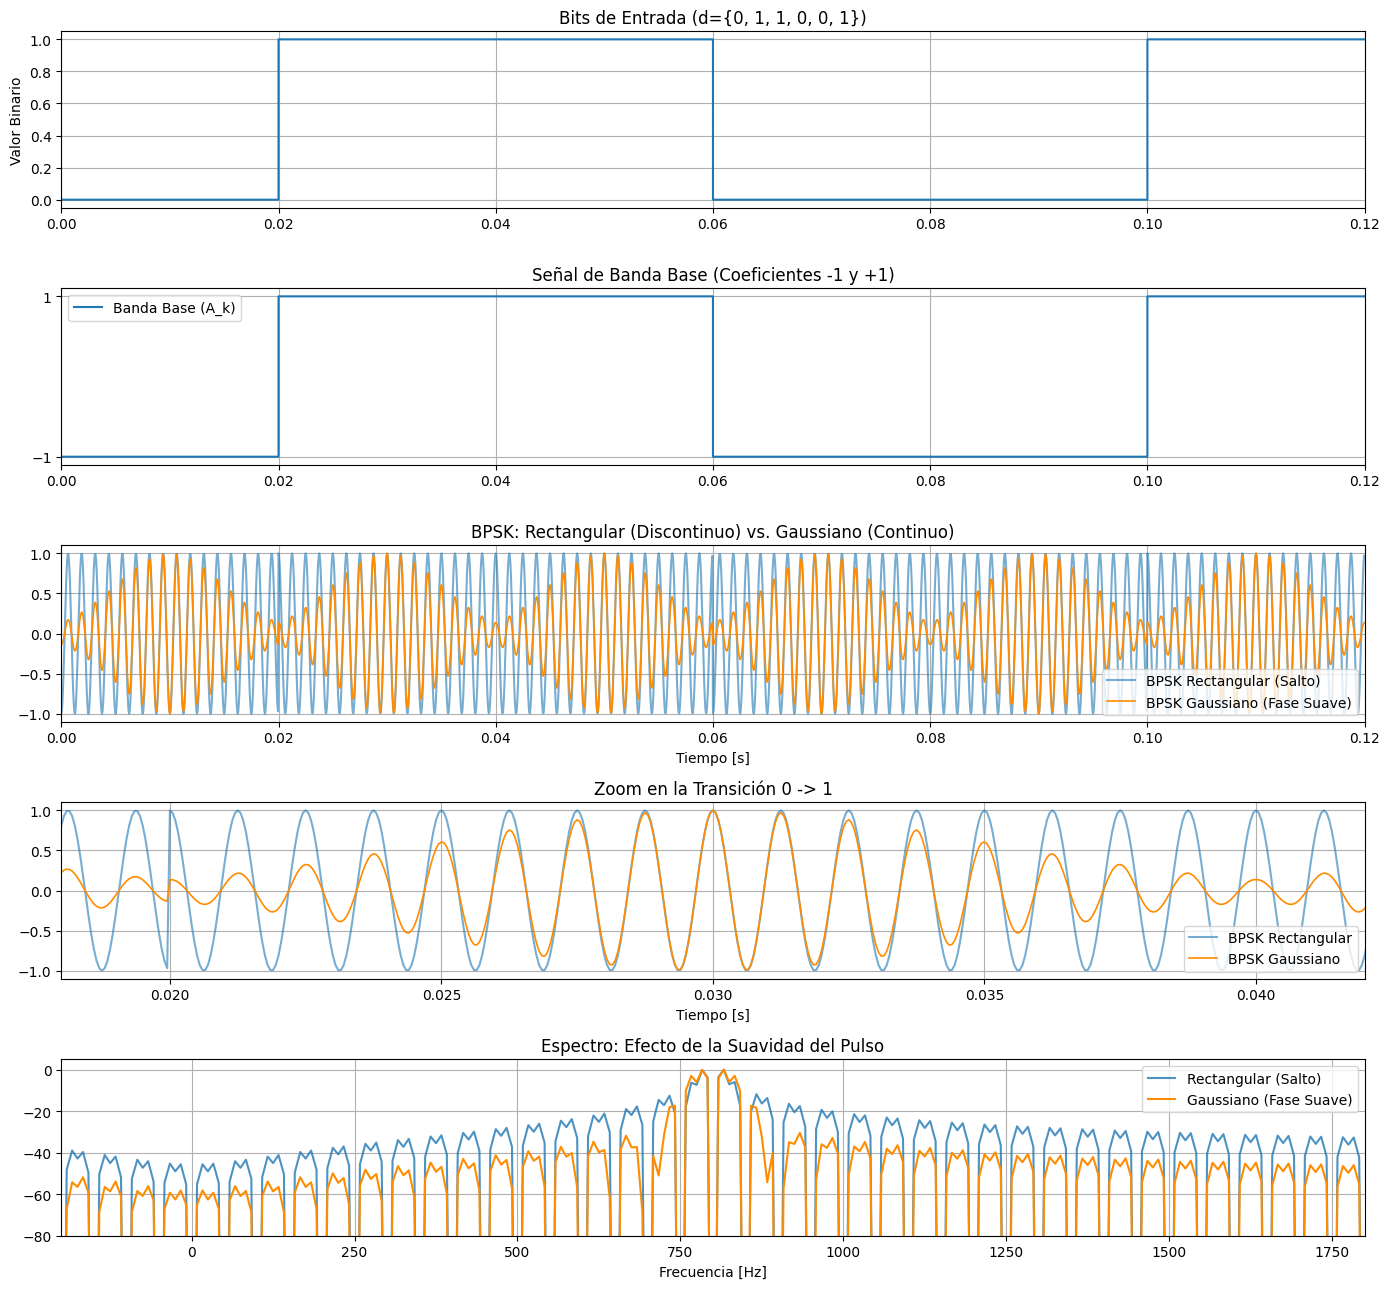

In [ ]:
# ====================================================================
# F) BPSK con Fase Continua (CP-BPSK Implícito)
#    Comparación entre Pulso Rectangular (Salto de Fase) y Pulso Gaussiano (Fase Suave)
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parámetros Base
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])  # Secuencia binaria
fs = 20000                          # Frecuencia de muestreo [Hz]
Tsym = 0.02                         # Duración del símbolo [s]
fc = 800                            # Frecuencia portadora [Hz]
a = 1.0                             # Amplitud constante (A)
T_total = len(bits) * Tsym          # Tiempo total

# Parámetros del Pulso Gaussiano
sigma_frac = 0.25                   # Fracción de Tsym para sigma
sigma = sigma_frac * Tsym

# -----------------------
# Vectores de Tiempo y Amplitud
# -----------------------
t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

phi_rect = np.zeros_like(t)         # Fase para BPSK Rectangular: 0 o pi
env_gauss = np.zeros_like(t)        # Envolvente Gaussiana
signal_banda_base = np.zeros_like(t) # Señal de banda base modulada (-1 o +1)

# -----------------------
# Generación de la Señal BPSK (Constelación: 0->-1, 1->+1)
# -----------------------
for k, b in enumerate(bits):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym
    i = int(b)

    # 1. Pulso Gaussiano Local
    tt = t[idx0:idx1] - (k*Tsym + Tsym/2.0)
    g = np.exp(-0.5*(tt/sigma)**2); g = g / (g.max()+1e-16)
    env_gauss[idx0:idx1] = g

    # 2. Coeficiente de Constelación (Banda Base): [0 -> -1] y [1 -> +1]
    # Usamos (2*i - 1) para mapear 0->-1 y 1->1
    Ak = (2*i - 1)
    signal_banda_base[idx0:idx1] = Ak

    # 3. Fase BPSK Rectangular (para referencia): alfai(t) = di * pi
    # Esta fase solo se usa para la señal rectangular de referencia
    phi_rect[idx0:idx1] = i * np.pi

# -----------------------
# Señales Finales
# -----------------------

# 1. BPSK Rectangular (Salto de Fase de 180°): Usa la fase discontinua
s_bpsk_rect_fase = a * np.cos(2*np.pi*fc*t + phi_rect)

# 2. BPSK Pulso Rectangular (Banda Base): Alternativa, se obtiene el mismo resultado que 1
# BPSK es equivalente a la multiplicación de la banda base por la portadora.
s_bpsk_rect_bb = a * signal_banda_base * np.cos(2*np.pi*fc*t)

# 3. BPSK Pulso Gaussiano (Fase Continua Implícita): Multiplicación de la banda base suavizada por la portadora
# La suavidad viene del producto de la envolvente Gaussiana por la portadora.
s_bpsk_gauss_bb = a * signal_banda_base * env_gauss * np.cos(2*np.pi*fc*t)

# -----------------------
# FFT / Espectros
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag / (mag.max() + 1e-12))

f, sp_rect = fft_mag_db(s_bpsk_rect_bb, fs)
_, sp_gauss = fft_mag_db(s_bpsk_gauss_bb, fs)

# -----------------------
# Gráficas
# -----------------------
plt.figure(figsize=(14, 13))

# 1) Bits de entrada
plt.subplot(5, 1, 1)
plt.step(t, bits.repeat(Nsym), where='post');
plt.xlim(0, T_total)
plt.title('Bits de Entrada (d={0, 1, 1, 0, 0, 1})');
plt.ylabel('Valor Binario');
plt.grid(True)

# 2) Señal de Banda Base (Coeficientes de Amplitud)
plt.subplot(5, 1, 2)
plt.step(t, signal_banda_base, where='post', label='Banda Base (A_k)')
plt.xlim(0, T_total)
plt.yticks([-1, 1])
plt.legend(); plt.title('Señal de Banda Base (Coeficientes -1 y +1)'); plt.grid(True)


# 3) BPSK en el tiempo: Comparación de Pulso Rectangular vs. Gaussiano
plt.subplot(5, 1, 3)
plt.plot(t, s_bpsk_rect_bb, label='BPSK Rectangular (Salto)', alpha=0.6)
plt.plot(t, s_bpsk_gauss_bb, label='BPSK Gaussiano (Fase Suave)', color='darkorange', linewidth=1.2)
plt.xlim(0, T_total)
plt.legend(); plt.title(f'BPSK: Rectangular (Discontinuo) vs. Gaussiano (Continuo)'); plt.grid(True)
plt.xlabel('Tiempo [s]')


# 4) Zoom para ver la continuidad/discontinuidad
plt.subplot(5, 1, 4)
plt.plot(t, s_bpsk_rect_bb, label='BPSK Rectangular', alpha=0.6)
plt.plot(t, s_bpsk_gauss_bb, label='BPSK Gaussiano', color='darkorange', linewidth=1.2)
plt.xlim(Tsym*0.9, Tsym*2.1) # Zoom en la transición 0 -> 1
plt.legend(); plt.title('Zoom en la Transición 0 -> 1'); plt.grid(True)
plt.xlabel('Tiempo [s]')

# 5) Espectros: Comparación de Ancho de Banda
plt.subplot(5, 1, 5)
plt.plot(f, sp_rect, label='Rectangular (Salto)', alpha=0.8);
plt.plot(f, sp_gauss, label='Gaussiano (Fase Suave)', color='darkorange');
plt.xlim(fc - 1000, fc + 1000)
plt.ylim(-80, 5); plt.legend(); plt.title('Espectro: Efecto de la Suavidad del Pulso'); plt.grid(True)
plt.xlabel('Frecuencia [Hz]')


plt.tight_layout()
plt.show()

#B-FSK

#  Especificaciones para Simulación de B-FSK (Binary Frequency Shift Keying)

Esta configuración describe la modulación **B-FSK**, donde la información se codifica mediante un **cambio de frecuencia** ($\Delta f$). Se utiliza un **pulso rectangular** y una fase que varía linealmente.

## 1. Código Principal: B-FSK con Pulso Rectangular

**Secuencia de bits de entrada ($d$):**
La secuencia de datos binarios a modular es:
$$
d = \{0, 1, 1, 0, 0, 1\}
$$

**Dominio de los bits individuales ($d_i$):**
Cada elemento $d_i$ en la secuencia $d$ pertenece al conjunto de valores binarios:
$$
d_i \in \{0, 1\}, \quad \forall i
$$

**Representación de la señal modulada ($s(t)$):**
La señal modulada en el tiempo es:
$$
s(t) = a_i \cdot v_i(t) \cdot \cos(\omega_0 t + \alpha_i(t))
$$
donde $\omega_0 = 2\pi f_c$.

**Amplitudes de la señal ($a_i$):**
La amplitud se mantiene **constante** ($A$) y positiva, ya que FSK no modula la potencia:
$$
a_i \in \{a_0, a_1, \dots \}, \quad \text{donde } a_i \in \mathbb{R}^+
$$

**Función de pulso base ($v_i(t)$):**
Se utiliza el pulso **rectangular**, lo que da una amplitud constante durante el intervalo $\tau$:
$$
v_i(t) = \text{rect}_{\tau}(t), \quad \forall i, t \in \text{TAO}
$$

**Componente de fase/ángulo ($\alpha_i(t)$):**
La fase es una **función lineal simple del tiempo** dentro del símbolo, lo que induce el cambio de frecuencia.
$$
\alpha_i(t) = (2d_i - 1) \cdot t
$$
* **Si $d_i = 1$:** $\alpha_i(t) = +t \implies \text{Pendiente Positiva / Frecuencia Alta } (f_c + \Delta f)$
* **Si $d_i = 0$:** $\alpha_i(t) = -t \implies \text{Pendiente Negativa / Frecuencia Baja } (f_c - \Delta f)$

---
**Objetivo de la simulación:** Implementar **B-FSK** utilizando la fase lineal simple y el pulso rectangular. La señal debe mostrar una diferencia de frecuencia en la portadora en cada símbolo, con amplitudes abruptas en los bordes.

#  Explicación de la Discontinuidad en la Fase FSK Literal

La gráfica de fase para el **B-FSK** con pulso rectangular, usando la fórmula de tu profesor $\mathbf{\alpha_i(t) = (2d_i - 1) \cdot t}$ y sin acumulación de fase, se ve como una serie de rampas **discontinuas** (con saltos verticales) por la forma en que se define y se implementa el tiempo en el código.

## 1. Implementación de la Fase Local

* **Reinicio del Tiempo:** En la implementación del código, el vector de tiempo $t$ se reinicia efectivamente al inicio de cada símbolo $\tau$. Es decir, el tiempo local ($\mathbf{t_{\text{local}}}$) siempre comienza en **cero** al inicio de un nuevo bit.
* **Fase No Acumulada:** La fórmula solo calcula la fase *dentro* del símbolo actual.

## 2. Origen del Salto Vertical

Cuando el código pasa del símbolo $k$ al símbolo $k+1$:

* **Fin del Símbolo $k$:** La fase $\alpha_k$ termina en un valor grande (por ejemplo, $\mathbf{+20 \text{ radianes}}$ o $\mathbf{-20 \text{ radianes}}$), que es el resultado de $\mathbf{K_\phi \cdot T_{\text{sym}}}$.
* **Inicio del Símbolo $k+1$:** La fase $\alpha_{k+1}$ debe comenzar en el valor dictado por la nueva rampa, que es $\mathbf{\alpha_{k+1} = \pm K_\phi \cdot (0)}$. Por lo tanto, comienza en **cero radianes**.

El salto vertical se debe a la **diferencia abrupta** entre el valor final del segmento anterior ($\pm 20 \text{ rad}$) y el valor inicial del nuevo segmento ($0 \text{ rad}$).

$$\text{Salto Vertical} = \text{Fase Final Anterior} - \text{Fase Inicial Nueva} \approx (\pm 20 \text{ rad}) - (0 \text{ rad})$$

## 3. Implicación de la Discontinuidad

* **Interpretación Literal:** La gráfica **discontinua** es la representación **literal** de la fórmula si se implementa sin considerar la continuidad histórica de la fase.
* **Necesidad Práctica:** En la práctica de las telecomunicaciones, esta discontinuidad de fase genera un **espectro sucio y amplio**. Por esta razón, la modulación B-FSK casi siempre se implementa con **Fase Continua (CPFSK)**, que es la gráfica de rampas **conectadas** (sin saltos verticales).

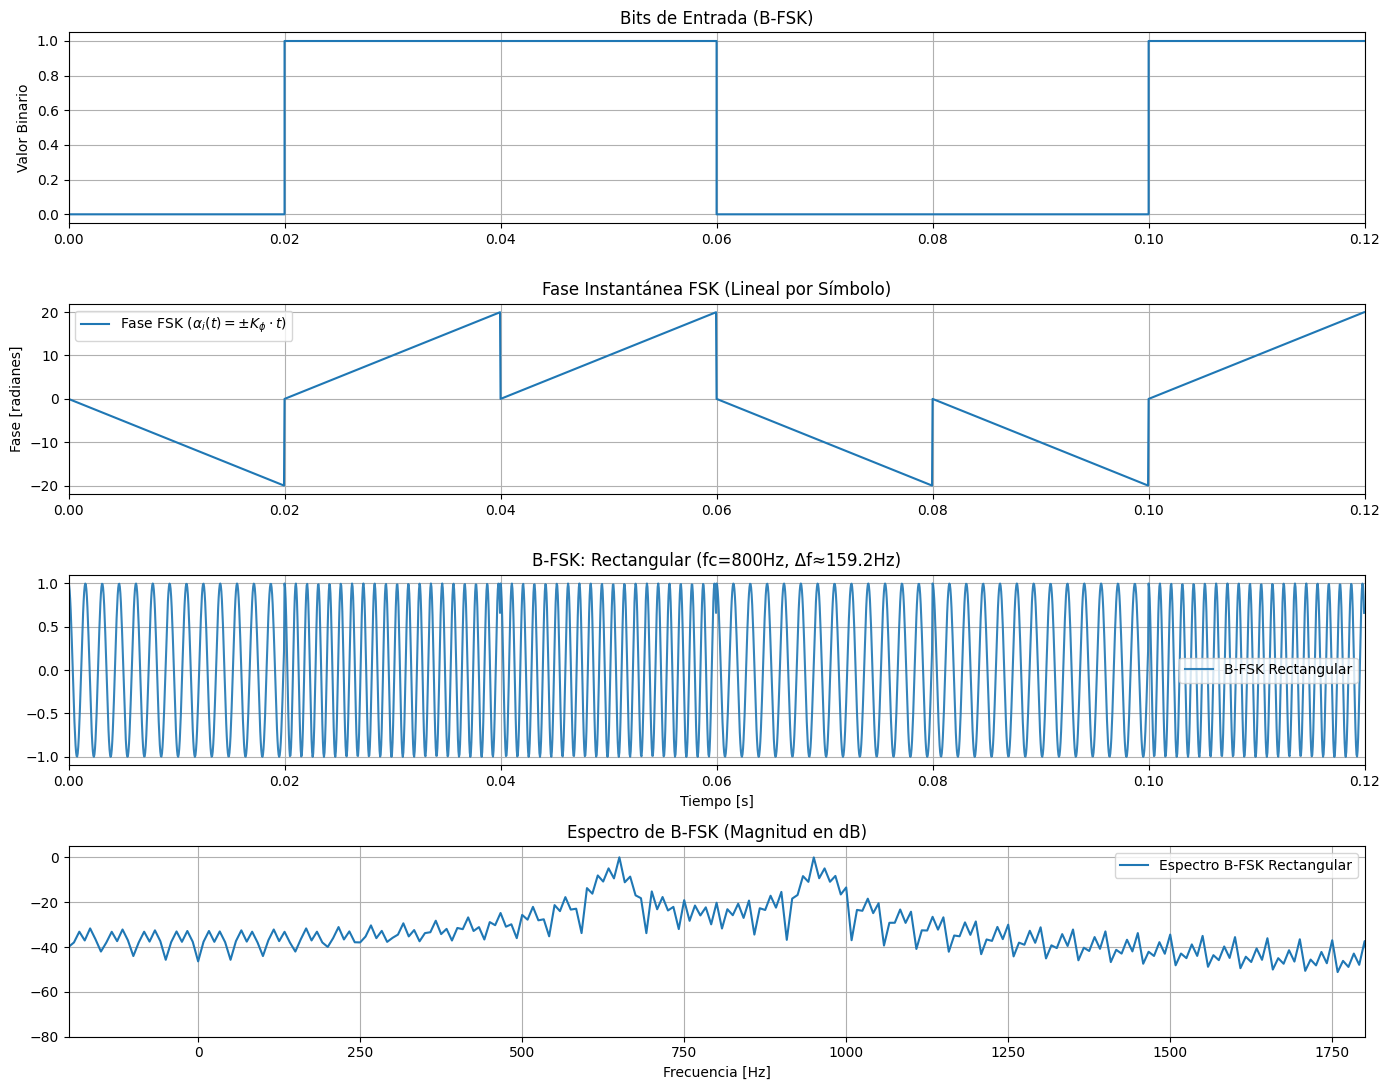

In [ ]:
# ====================================================================
# G) B-FSK (Binary Frequency Shift Keying) con Fase Lineal Simple
#    Pulso Rectangular (v_i(t) = rect) y Fase: (2di - 1) * t
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parámetros Base
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])  # Secuencia binaria
fs = 20000                          # Frecuencia de muestreo [Hz]
Tsym = 0.02                         # Duración del símbolo [s]
fc = 800                            # Frecuencia portadora [Hz]
a = 1.0                             # Amplitud constante (A)
T_total = len(bits) * Tsym          # Tiempo total

# K_phi: Pendiente de la fase lineal. Usamos un valor alto (como 1000) para hacer
# que el cambio de frecuencia (Δf = K_phi / 2π) sea visible frente a fc=800Hz.
K_phi = 1000.0

# -----------------------
# Vectores de Tiempo
# -----------------------
t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

env_rect = np.ones_like(t) * a      # Envolvente Rectangular
phi_fsk = np.zeros_like(t)          # Fase Lineal

# -----------------------
# Generación de la Señal B-FSK
# -----------------------
for k, b in enumerate(bits):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym
    i = int(b)

    # El tiempo 't' es absoluto, pero el offset garantiza que la pendiente
    # se aplique sobre el intervalo de ese símbolo.
    t_local_offset = t[idx0:idx1] - (k * Tsym)

    # 1. Fase FSK: alfai(t) = K_phi * (2di - 1) * t_local
    # Usamos t_local_offset para que la fase comience desde el inicio del símbolo
    phi_fsk[idx0:idx1] = K_phi * (2*i - 1) * t_local_offset

# 2. Señal B-FSK (Pulso Rectangular)
s_fsk_rect = env_rect * np.cos(2*np.pi*fc*t + phi_fsk)

# -----------------------
# FFT / Espectro
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag / (mag.max() + 1e-12))

f, sp_fsk = fft_mag_db(s_fsk_rect, fs)

# -----------------------
# Gráficas
# -----------------------
plt.figure(figsize=(14, 11))

# 1) Bits de entrada
plt.subplot(4, 1, 1)
plt.step(t, bits.repeat(Nsym), where='post');
plt.xlim(0, T_total)
plt.title('Bits de Entrada (B-FSK)');
plt.ylabel('Valor Binario');
plt.grid(True)

# 2) Fase Instantánea (Rampa con Jumps)
plt.subplot(4, 1, 2)
plt.plot(t, phi_fsk, label=r'Fase FSK ($\alpha_i(t) = \pm K_\phi \cdot t$)')
plt.xlim(0, T_total)
plt.legend(); plt.title('Fase Instantánea FSK (Lineal por Símbolo)'); plt.grid(True)
plt.ylabel('Fase [radianes]')


# 3) Señal B-FSK (Tiempo) - Pulso Rectangular
plt.subplot(4, 1, 3)
plt.plot(t, s_fsk_rect, label='B-FSK Rectangular', alpha=0.9)
plt.xlim(0, T_total)
plt.legend(); plt.title(f'B-FSK: Rectangular (fc={fc}Hz, Δf≈{K_phi/(2*np.pi):.1f}Hz)'); plt.grid(True)
plt.xlabel('Tiempo [s]')


# 4) Espectro
plt.subplot(4, 1, 4)
plt.plot(f, sp_fsk, label='Espectro B-FSK Rectangular');
plt.xlim(fc - 1000, fc + 1000)
plt.ylim(-80, 5); plt.legend(); plt.title('Espectro de B-FSK (Magnitud en dB)'); plt.grid(True)
plt.xlabel('Frecuencia [Hz]')

plt.tight_layout()
plt.show()

#CPM

#  Especificaciones para Simulación de Modulación por Fase Continua (CPM)

La **Modulación por Fase Continua (CPM)** es una familia de esquemas de modulación digital cuya característica principal es garantizar que la **fase de la portadora sea continua** en todos los instantes de tiempo. Esto se logra haciendo que el cambio de fase entre los símbolos no sea abrupto.

## 1. Características Fundamentales de CPM
* **Continuidad de Fase:** La fase $\phi(t)$ es una función suave (rampas conectadas). Es esencial para **reducir el ancho de banda** del espectro (eficiencia espectral) y evitar la reemisión de energía en los lóbulos laterales.
* **Amplitud Constante:** La envolvente $A$ se mantiene constante. Esto permite el uso de **Amplificadores de Potencia (PA) no lineales**, que son más eficientes (eficiencia de potencia).

## 2. Representación de la Señal CPM ($s(t)$)
La forma general de la señal CPM es:
$$
s(t) = A \cdot \cos(\omega_0 t + \phi(t, \mathbf{d}))
$$
donde:
* $A$: es la amplitud constante.
* $\omega_0$: es la frecuencia angular de la portadora.
* $\phi(t, \mathbf{d})$: es la **función de fase total**, que depende de la secuencia de bits $\mathbf{d}$ y está diseñada para ser continua.

## 3. La Función de Fase Total $\phi(t, \mathbf{d})$
La fase total $\phi(t, \mathbf{d})$ es la **acumulación** de la fase anterior ($\phi_k$) más la fase generada por el símbolo actual ($d_k$):

$$
\phi(t, \mathbf{d}) = \phi_k + 2\pi h \sum_{i=0}^k d_i \cdot q(t - i\tau)
$$

* $\phi_k$: Fase acumulada al inicio del símbolo actual.
* $h$: **Índice de Modulación**, un valor clave que define la cantidad de cambio de fase por símbolo.
* $d_i$: Símbolo de datos (valores $\pm 1$).
* $q(t)$: La **respuesta de fase** de pulsos suaves, que es la integral de la función de pulso de frecuencia $g(t)$.

---

## 4. El Caso Especial: MSK (Minimum Shift Keying)

**MSK** es el esquema CPM que logra la máxima eficiencia espectral. Se define por la imposición del **índice de modulación $h=0.5$**.

### A. Condición de Integridad de la Portadora
La restricción $\omega_0\tau = 2\pi K$, donde $K \in \mathbb{Z}$ (enteros), junto con $h=0.5$, asegura que la portadora sea "casi periódica" en cada intervalo de símbolo $\tau$.

### B. Significado del Índice $h=0.5$ (Ortogonalidad y Mínimo Ancho de Banda)

El valor $\mathbf{h=0.5}$ es crucial porque:

1.  **Garantiza Ortogonalidad:** Obliga a que el cambio de fase **local** ($\mathbf{\Delta\phi}$) en cada símbolo sea **exactamente $\pm 90^{\circ}$** ($\pm \pi/2$ radianes):

    $$
    \Delta \phi = \pi \cdot h \cdot d_k = \pm \pi/2
    $$
    Este cambio de fase $\pm 90^\circ$ es el **mínimo** necesario para que las dos frecuencias ($f_c \pm \Delta f$) sean **ortogonales** (perfectamente distinguibles por el receptor).

2.  **Mínimo Desplazamiento ($\Delta f$):** Resulta en el menor desplazamiento de frecuencia posible:
    $$
    \Delta f_{\text{MSK}} = \frac{h}{2 \cdot \tau} = \frac{1}{4 \cdot \tau}
    $$
    Este mínimo $\Delta f$ asegura que el espectro sea lo **más estrecho** posible.

---
**Objetivo de la simulación:** Implementar un esquema CPM simple, como el **MSK/CPFSK** ($g(t)$ rectangular y $h=0.5$), destacando la **fase continua acumulada** y la **alta eficiencia espectral** resultante.

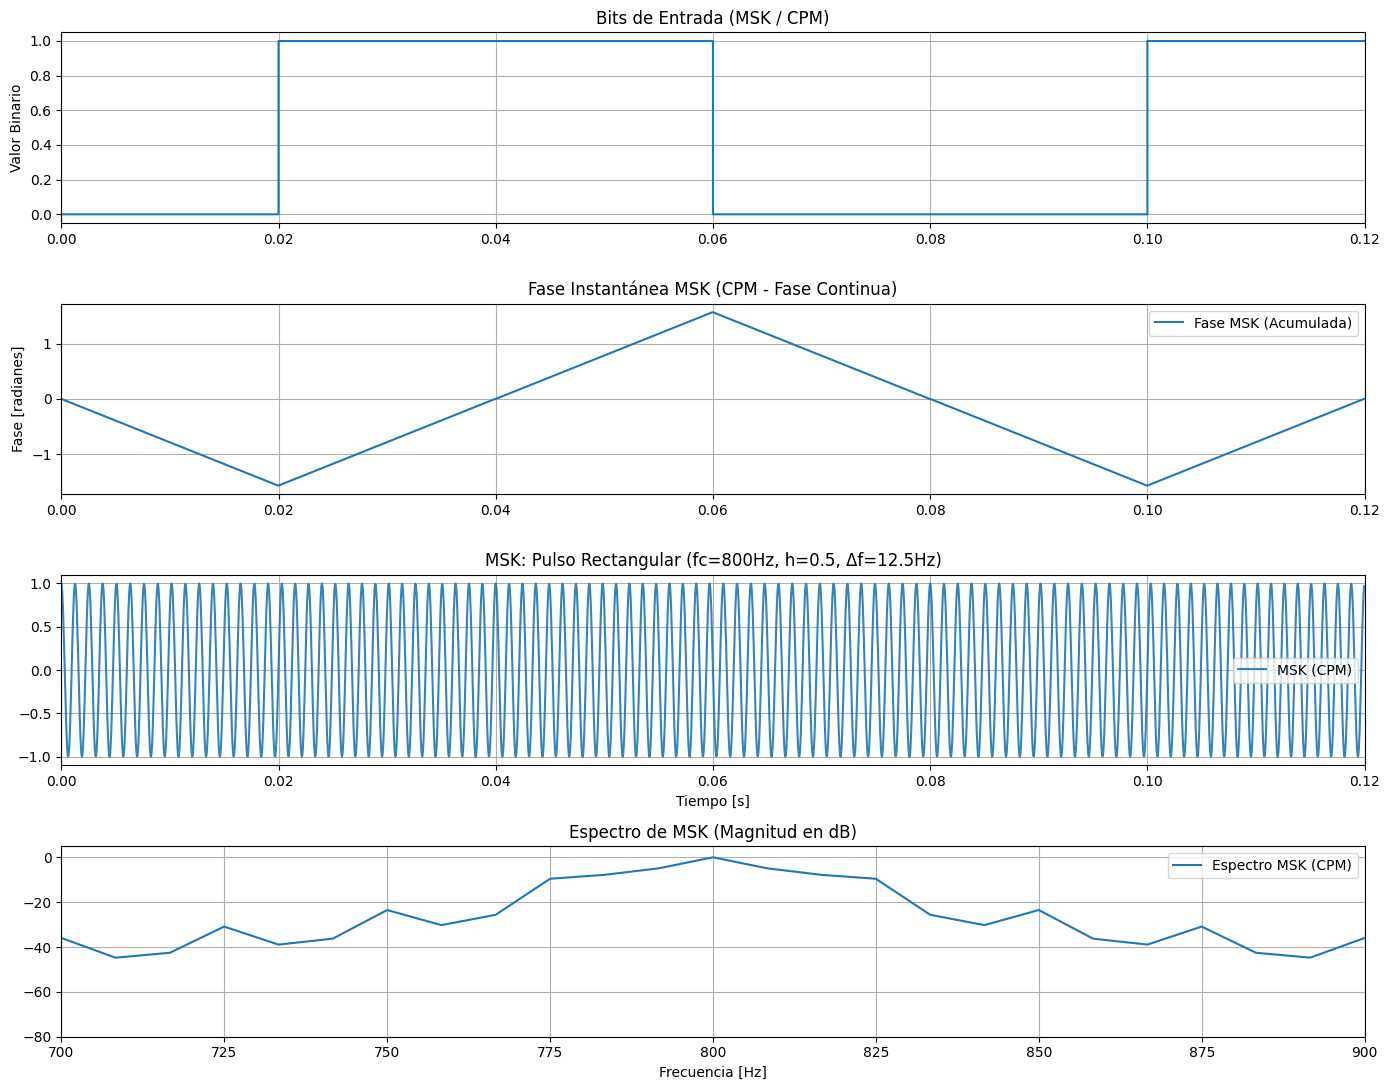

In [ ]:
# ====================================================================
# H) MSK (Minimum Shift Keying) - Un esquema de CPM
#    Pulso de Frecuencia Rectangular (g(t)) y Fase Continua Acumulada
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parámetros Base
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])  # Secuencia binaria
fs = 20000                          # Frecuencia de muestreo [Hz]
Tsym = 0.02                         # Duración del símbolo [s]
fc = 800                            # Frecuencia portadora [Hz]
a = 1.0                             # Amplitud constante (A)
T_total = len(bits) * Tsym

# Parámetros MSK clave:
h = 0.5                             # Índice de Modulación (h=0.5 para MSK)
# El cambio de frecuencia (Δf) se define por h: Δf = h / (2 * Tsym)
delta_f = h / (2 * Tsym)           # Δf = 0.5 / (2 * 0.02) = 12.5 Hz

# Factor K_phi (Pendiente de Fase): K_phi = 2 * pi * Δf
K_phi = 2 * np.pi * delta_f         # K_phi ≈ 78.54 rad/s

# -----------------------
# Vectores de Tiempo
# -----------------------
t_sym = np.arange(0, Tsym, 1/fs)
t = np.concatenate([t_sym + k*Tsym for k in range(len(bits))])
Nsym = len(t_sym)

env_rect = np.ones_like(t) * a
phi_msk = np.zeros_like(t)
fase_final_anterior = 0.0           # FASE ACUMULADA (Clave para CPM)

# -----------------------
# Generación de la Señal MSK (FASE ACUMULADA)
# -----------------------
# Mapeo de bits: 0 -> -1, 1 -> +1
symbols = 2 * bits - 1

for k, d_k in enumerate(symbols):
    idx0 = k*Nsym; idx1 = (k+1)*Nsym

    t_local = t[idx0:idx1] - (k * Tsym) # Tiempo local de 0 a Tsym

    # 1. Pendiente de Fase (Factor de Frecuencia): d_k * K_phi
    pendiente = d_k * K_phi

    # 2. FASE MSK (Continua): Fase acumulada + Rampa local
    # phi(t) = phi_anterior + d_k * K_phi * t_local
    fase_segmento = fase_final_anterior + pendiente * t_local

    phi_msk[idx0:idx1] = fase_segmento

    # 3. Actualizar la fase final para el próximo símbolo
    fase_final_anterior = fase_segmento[-1]

# 2. Señal MSK
s_msk = env_rect * np.cos(2*np.pi*fc*t + phi_msk)

# -----------------------
# FFT / Espectro
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag / (mag.max() + 1e-12))

f, sp_msk = fft_mag_db(s_msk, fs)

# -----------------------
# Gráficas
# -----------------------
plt.figure(figsize=(14, 11))

# 1) Bits de entrada
plt.subplot(4, 1, 1)
plt.step(t, bits.repeat(Nsym), where='post');
plt.xlim(0, T_total)
plt.title('Bits de Entrada (MSK / CPM)');
plt.ylabel('Valor Binario');
plt.grid(True)

# 2) Fase Instantánea (Rampa Continua)
plt.subplot(4, 1, 2)
plt.plot(t, phi_msk, label=r'Fase MSK (Acumulada)')
plt.xlim(0, T_total)
plt.legend(); plt.title('Fase Instantánea MSK (CPM - Fase Continua)'); plt.grid(True)
plt.ylabel('Fase [radianes]')


# 3) Señal MSK (Tiempo)
plt.subplot(4, 1, 3)
plt.plot(t, s_msk, label='MSK (CPM)', alpha=0.9)
plt.xlim(0, T_total)
plt.legend(); plt.title(f'MSK: Pulso Rectangular (fc={fc}Hz, h={h}, Δf={delta_f}Hz)'); plt.grid(True)
plt.xlabel('Tiempo [s]')


# 4) Espectro
plt.subplot(4, 1, 4)
plt.plot(f, sp_msk, label='Espectro MSK (CPM)');
plt.xlim(fc - 100, fc + 100) # Zoom en +/- 100 Hz
plt.ylim(-80, 5); plt.legend(); plt.title('Espectro de MSK (Magnitud en dB)'); plt.grid(True)
plt.xlabel('Frecuencia [Hz]')


plt.tight_layout()
plt.show()

#  Especificaciones para Simulación de Modulación GMSK (Gaussian Minimum Shift Keying)

**GMSK** es el esquema CPM más avanzado, utilizado en estándares como GSM y Bluetooth. Combina la fase continua con un desplazamiento de frecuencia mínimo ($h=0.5$) y un pulso Gaussiano para lograr una **eficiencia espectral superior** al MSK estándar.

## 1. Características Fundamentales de GMSK
* **Fase Continua (CPM):** La fase $\phi(t)$ se acumula suavemente (integración de la Gaussiana), eliminando discontinuidades.
* **Amplitud Constante:** La envolvente $A$ se mantiene constante, permitiendo el uso de amplificadores de potencia eficientes.

## 2. Parámetros Clave de MSK/GMSK
* **Índice de Modulación ($h$):** $\mathbf{h = 0.5}$. Este valor garantiza la **ortogonalidad** ($\Delta \phi = \pm 90^{\circ}$) y el **mínimo desplazamiento de frecuencia** ($\Delta f$).
* **Función de Pulso de Frecuencia ($g(t)$):** Una función **Gaussiana** truncada.

## 3. La Función de Fase Total $\phi(t, \mathbf{d})$
La fase total es la integral (acumulación) del pulso de frecuencia efectivo (secuencia de bits filtrada por la Gaussiana):
$$
\phi(t, \mathbf{d}) = 2\pi h \sum_{i} d_i \cdot q(t - i\tau)
$$
Donde $q(t)$ es la integral de la respuesta al impulso Gaussiano.

### Parámetro de Suavizado ($B \cdot T_{\text{sym}}$)
Se utiliza el parámetro $B \cdot T_{\text{sym}}$ para controlar la anchura del filtro Gaussiano:
* **$B \cdot T_{\text{sym}} = 0.3$** (Valor típico de GSM): Produce un filtro estrecho, lo que resulta en la máxima suavidad de la fase y el **espectro más compacto** posible, con lóbulos laterales atenuados rápidamente.

---
**Objetivo de la simulación:** Implementar GMSK ($h=0.5$ y $BT=0.3$) para visualizar la **trayectoria de fase curva y suave** y demostrar la **máxima eficiencia espectral** del espectro.

/tmp/ipython-input-1429442456.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  g_t /= np.trapz(g_t, t_gauss)  # Normalizar el área a 1


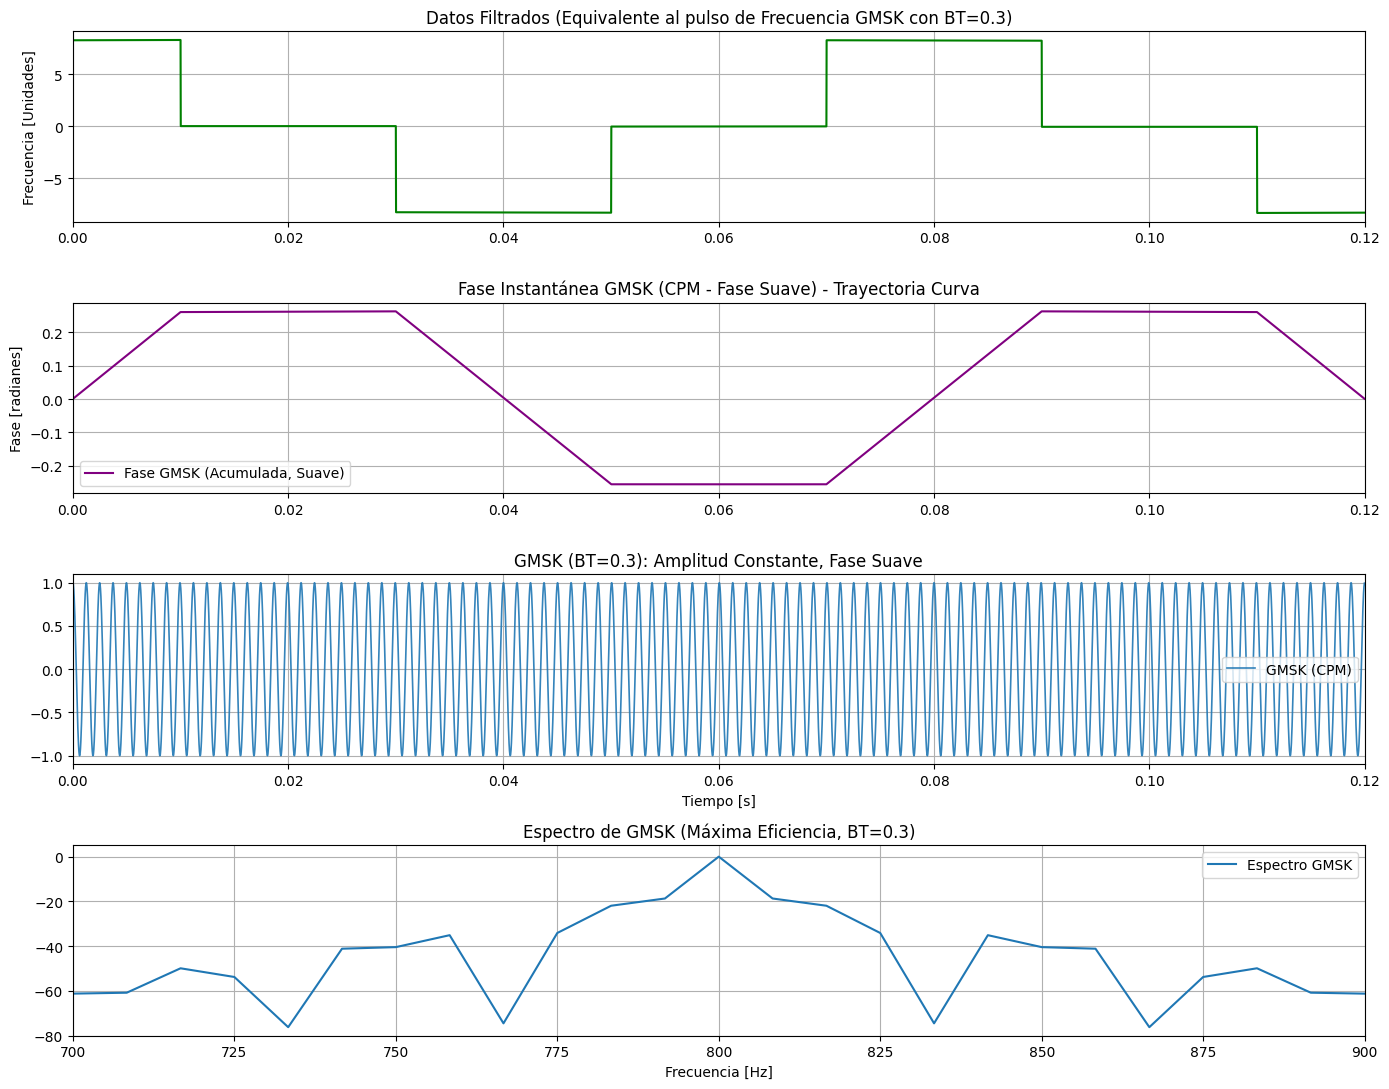

In [14]:
# ====================================================================
# GMSK (Gaussian Minimum Shift Keying) - CPM Avanzado (FINAL)
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# -----------------------
# Parámetros GMSK
# -----------------------
bits = np.array([0, 1, 1, 0, 0, 1])
fs = 50000                 # Frecuencia de muestreo [Hz]
Tsym = 0.02                # Duración del símbolo [s]
fc = 800                   # Frecuencia portadora [Hz]
a = 1.0                    # Amplitud constante (A)
h = 0.5                    # Índice de Modulación (h=0.5 para MSK)
BT = 0.3                   # Ancho de banda * Tsym (Típico GSM = 0.3)
T_total = len(bits) * Tsym
Nsym = int(fs * Tsym)      # Número de muestras por símbolo

# -----------------------
# Vectores de Tiempo
# -----------------------
t = np.arange(0, T_total, 1/fs)
t = t[:len(bits) * Nsym]

# -----------------------
# Generación del Pulso Gaussiano g(t)
# -----------------------
pulse_span = 6  # Pulso de 6 símbolos de ancho
t_gauss = np.arange(-pulse_span/2 * Tsym, pulse_span/2 * Tsym, 1/fs)

# 1. Pulso de Frecuencia Gaussiano g(t)
alpha = (2 * np.pi * BT) / (np.sqrt(np.log(2)))
g_t = (alpha / (2 * np.pi)) * np.exp(-0.5 * (alpha * t_gauss)**2)
g_t /= np.trapz(g_t, t_gauss)  # Normalizar el área a 1

# -----------------------
# Convolución para obtener el Pulso de Frecuencia Efectivo
# -----------------------
symbols = 2 * bits - 1  # Mapeo de bits: 0 -> -1, 1 -> +1
impulse_data = np.zeros_like(t)
for k, d_k in enumerate(symbols):
    # Colocamos el impulso en el centro del intervalo
    impulse_data[k*Nsym + Nsym//2] = d_k

# Convolución: Símbolos * Pulso Gaussiano
f_pulse_eff = convolve(impulse_data, g_t, mode='same', method='fft')

# -----------------------
# Generación de la Señal GMSK (FASE ACUMULADA)
# -----------------------
# La fase es la integral discreta del pulso de frecuencia efectivo
phi_gmsk = np.cumsum(2 * np.pi * h * f_pulse_eff) / fs

# 2. Señal GMSK
s_gmsk = a * np.cos(2*np.pi*fc*t + phi_gmsk)

# -----------------------
# FFT / Espectro
# -----------------------
def fft_mag_db(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag = np.abs(X)
    return f, 20*np.log10(mag / (mag.max() + 1e-12))

f, sp_gmsk = fft_mag_db(s_gmsk, fs)

# -----------------------
# Gráficos
# -----------------------
plt.figure(figsize=(14, 11))

# 1) Datos Filtrados (Pulso de Frecuencia Efectivo)
plt.subplot(4, 1, 1)
plt.plot(t, f_pulse_eff, label='Pulso de Frecuencia Efectivo (Gaussiano)', color='green')
plt.xlim(0, T_total)
plt.title(f'Datos Filtrados (Equivalente al pulso de Frecuencia GMSK con BT={BT})')
plt.grid(True)
plt.ylabel('Frecuencia [Unidades]')

# 2) Fase Instantánea (Rampa Continua SUAVE)
plt.subplot(4, 1, 2)
plt.plot(t, phi_gmsk, label='Fase GMSK (Acumulada, Suave)', color='purple')
plt.xlim(0, T_total)
plt.legend()
plt.title('Fase Instantánea GMSK (CPM - Fase Suave) - Trayectoria Curva')
plt.grid(True)
plt.ylabel('Fase [radianes]')

# 3) Señal GMSK (Tiempo)
plt.subplot(4, 1, 3)
plt.plot(t, s_gmsk, label='GMSK (CPM)', alpha=0.9, linewidth=1.2)
plt.xlim(0, T_total)
plt.legend()
plt.title(f'GMSK (BT={BT}): Amplitud Constante, Fase Suave')
plt.grid(True)
plt.xlabel('Tiempo [s]')

# 4) Espectro
plt.subplot(4, 1, 4)
plt.plot(f, sp_gmsk, label='Espectro GMSK')
plt.xlim(fc - 100, fc + 100)
plt.ylim(-80, 5)
plt.legend()
plt.title(f'Espectro de GMSK (Máxima Eficiencia, BT={BT})')
plt.grid(True)
plt.xlabel('Frecuencia [Hz]')

plt.tight_layout()
plt.show()
